In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
from ddpg_per import DDPG
from envs import TradingEnv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from multiprocessing import Pool, cpu_count
from scipy.stats import norm


I0000 00:00:1777138906.213777  892713 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777138906.282703  892713 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777138907.849355  892713 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Num GPUs Available: 0


E0000 00:00:1777138909.507171  892713 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


This notebook uses the trained model weights stored in the **model** folder for evaluation. It reproduces all results and figures presented in Sections <br> 
3. Results Reproduction and Robustness Tests
4. Stochastic Trading Costs Extension.

In [2]:
BASELINE_SABR = {
    "mu": 0.05,
    "vol": 0.20,
    "volvol": 0.60,
    "beta": 1.0,
    "rho": -0.4,
}


HIGH_VOL_SABR = {
    "mu": 0.05,
    "vol": 0.30,
    "volvol": 0.60,
    "beta": 1.0,
    "rho": -0.4,
}


# Results Reproduction and Robustness Tests

In [3]:
# This code is coherent with a state of dimension 3 

def make_agent(n_episodes = 1000):
    env = TradingEnv(
        continuous_action_flag=True,
        sabr_flag=True,
        dg_random_seed=42,
        init_ttm=20,
        trade_freq=1,
        spread=0.01,
        num_contract=1,
        num_sim=n_episodes,
        model_params=BASELINE_SABR,
    )
    return DDPG(env)


def flat_weights(model):
    return np.concatenate([w.reshape(-1) for w in model.get_weights()])


def load_checkpoint(tag):
    agent = make_agent()
    agent.load(tag=tag)
    return agent


def weight_stats(w_prev, w_curr):
    diff = w_curr - w_prev

    norm_prev = np.linalg.norm(w_prev)
    norm_curr = np.linalg.norm(w_curr)
    norm_diff = np.linalg.norm(diff)

    rel_diff = norm_diff / (norm_prev + 1e-12)

    cosine = np.dot(w_prev, w_curr) / (
        np.linalg.norm(w_prev) * np.linalg.norm(w_curr) + 1e-12
    )

    return norm_prev, norm_curr, norm_diff, rel_diff, cosine


## Learning stability : weights and hedging cost

To reporduce the csv file **analysis/weight_convergence_baseline_daily.csv**, run the following commented code. It contains weights norms from checkpoint to chechkpoint.

In [4]:
# checkpoint_tags = [f"baseline_daily{i}" for i in range(1, 51)]

# rows = []
# prev_agent = None
# prev_tag = None

# for tag in checkpoint_tags:
#     print("Loading", tag)
#     agent = load_checkpoint(tag)

#     if prev_agent is not None:
#         for model_name, model_prev, model_curr in [
#             ("actor", prev_agent.actor, agent.actor),
#             ("critic_q_ex", prev_agent.critic_q_ex, agent.critic_q_ex),
#             ("critic_q_ex2", prev_agent.critic_q_ex2, agent.critic_q_ex2),
#         ]:
#             w_prev = flat_weights(model_prev)
#             w_curr = flat_weights(model_curr)

#             norm_prev, norm_curr, norm_diff, rel_diff, cosine = weight_stats(
#                 w_prev, w_curr
#             )

#             rows.append({
#                 "from_checkpoint": prev_tag,
#                 "to_checkpoint": tag,
#                 "model": model_name,
#                 "norm_prev": norm_prev,
#                 "norm_curr": norm_curr,
#                 "norm_diff": norm_diff,
#                 "relative_diff": rel_diff,
#                 "cosine_similarity": cosine,
#             })

#     prev_agent = agent
#     prev_tag = tag


# df = pd.DataFrame(rows)
# print(df)

# df.to_csv("analysis/weight_convergence_baseline_daily.csv", index=False)

In [5]:
df = pd.read_csv("analysis/weight_convergence_baseline_daily.csv")

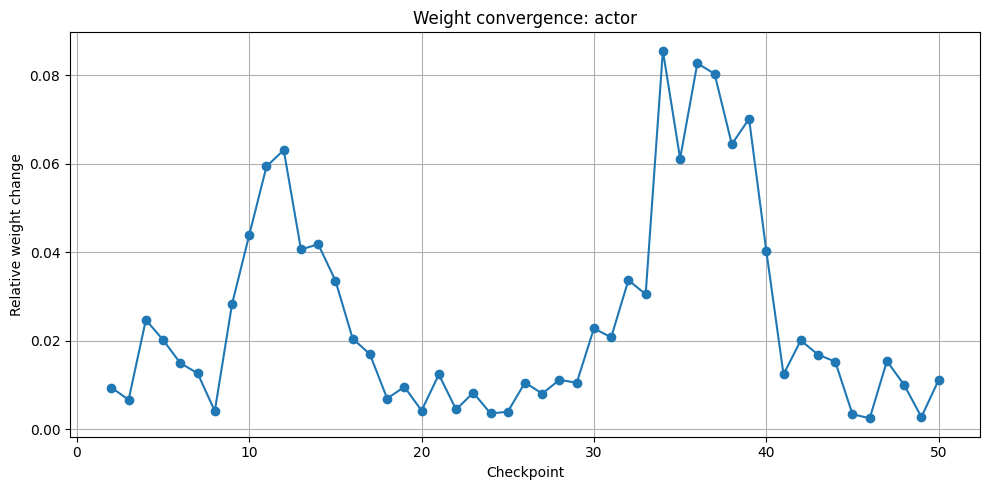

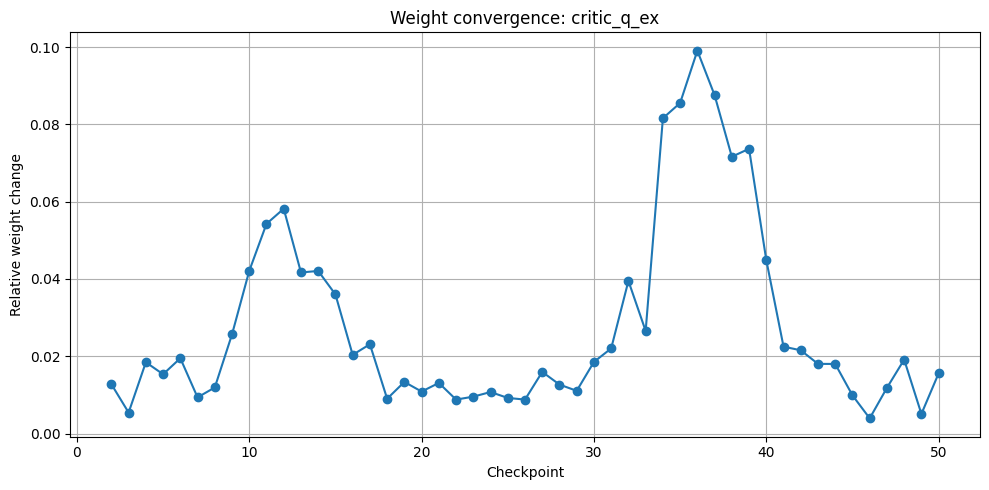

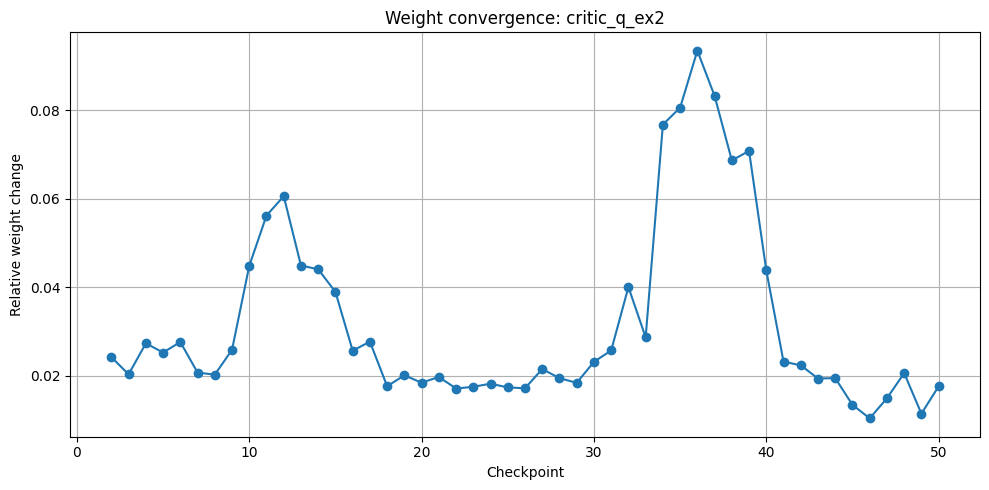

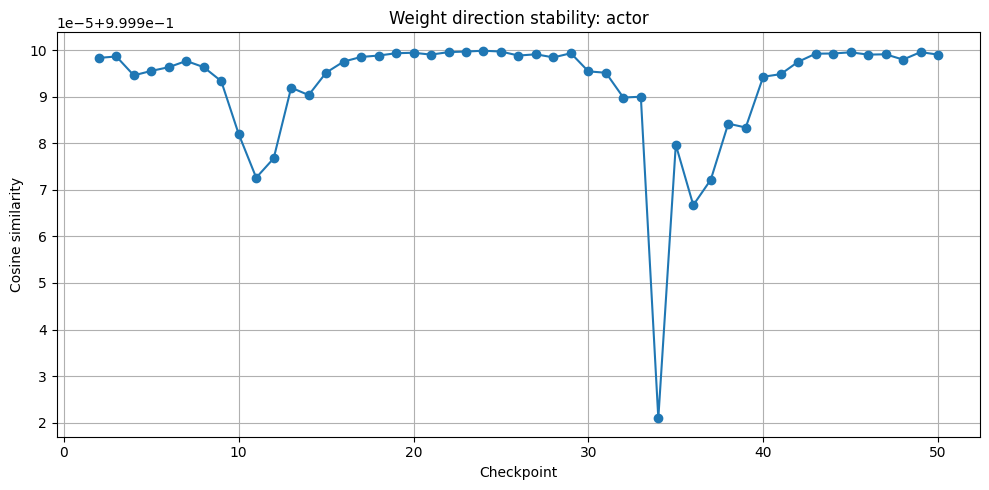

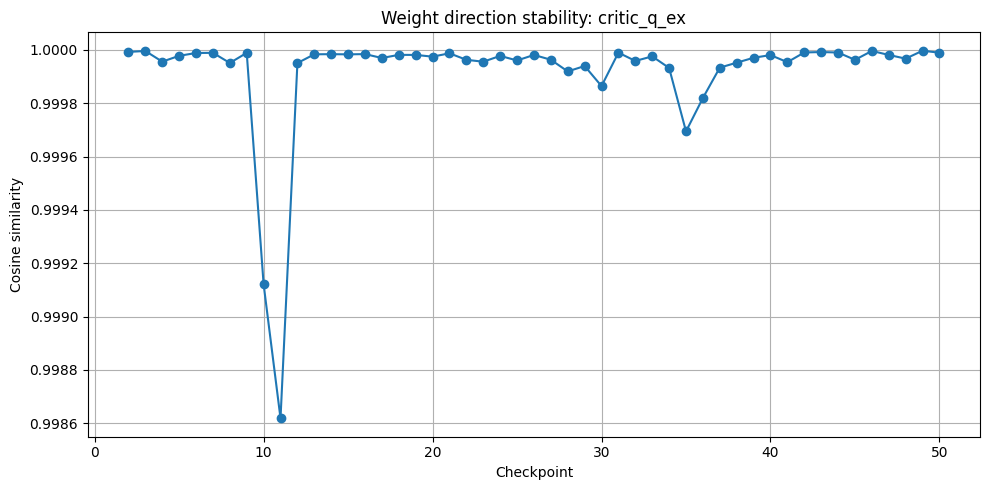

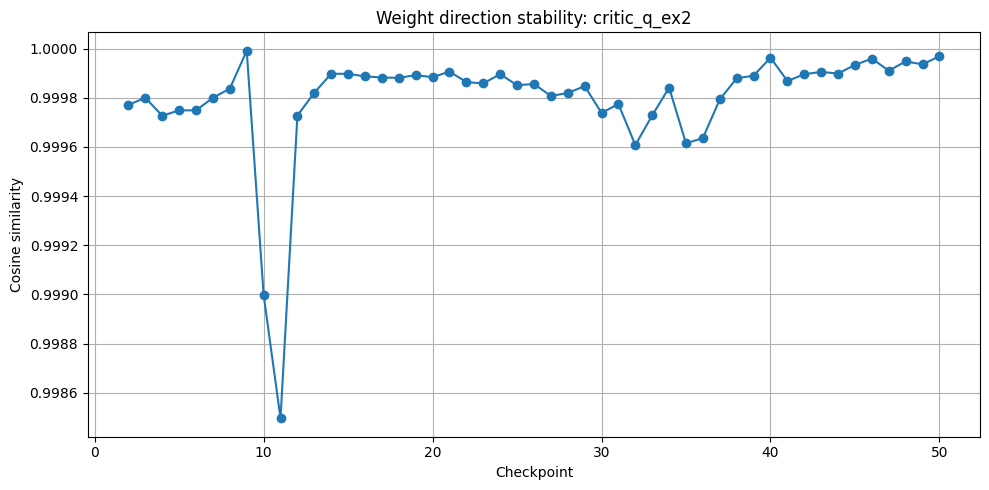

In [6]:
for model_name in df["model"].unique():
    sub = df[df["model"] == model_name]

    plt.figure(figsize=(10, 5))
    plt.plot(range(2, 51), sub["relative_diff"], marker="o")
    plt.xlabel("Checkpoint")
    plt.ylabel("Relative weight change")
    plt.title(f"Weight convergence: {model_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


for model_name in df["model"].unique():
    sub = df[df["model"] == model_name]

    plt.figure(figsize=(10, 5))
    plt.plot(range(2, 51), sub["cosine_similarity"], marker="o")
    plt.xlabel("Checkpoint")
    plt.ylabel("Cosine similarity")
    plt.title(f"Weight direction stability: {model_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [7]:
def compute_avg_reward_and_tc(tag, n_episodes=1000):
    agent = make_agent(n_episodes)
    env = agent.env
    agent.load(tag=tag)
    agent.epsilon = -1.0  # no exploration

    episode_rewards = []
    episode_tcs = []

    for ep in range(n_episodes):
        obs = env.reset()
        done = False

        total_reward = 0.0
        total_tc = 0.0

        while not done:
            current_price = float(env.state[0])
            current_position = float(env.state[1])

            x = np.asarray(obs).reshape(1, -1)
            action, _, _ = agent.egreedy_action(x)
            action = float(np.asarray(action).reshape(-1)[0])

            trade_size = action - current_position

            # constant transaction cost
            step_tc = abs(trade_size) * current_price * env.spread
            total_tc += step_tc

            obs, reward, done, _ = env.step(action)
            total_reward += float(reward)

        episode_rewards.append(total_reward)
        episode_tcs.append(total_tc)

    return {
        "avg_reward": np.mean(episode_rewards),
        "std_reward": np.std(episode_rewards),
        "avg_transaction_cost": np.mean(episode_tcs),
        "std_transaction_cost": np.std(episode_tcs),
        "avg_final_cost": -np.mean(episode_rewards),
    }

To reproduce the csv file **"analysis/stability_reward_tc_baseline.csv"** run the following commented code. It contains the evolution of statistics of sum of rewards and transaction costs from checkpoint to checkpoint.

In [8]:
# N_WORKERS = 256


# def evaluate_checkpoint(k):
#     tag = f"baseline_daily{k}"
#     print(f"Evaluating checkpoint {k}...")

#     out = compute_avg_reward_and_tc(tag, n_episodes=1000)

#     return {
#         "checkpoint": k,
#         "avg_reward": out["avg_reward"],
#         "std_reward": out["std_reward"],
#         "avg_transaction_cost": out["avg_transaction_cost"],
#         "std_transaction_cost": out["std_transaction_cost"],
#         "avg_final_cost": out["avg_final_cost"],
#     }


# if __name__ == "__main__":
#     checkpoints = list(range(1, 51))

#     with Pool(N_WORKERS) as pool:
#         results = pool.map(evaluate_checkpoint, checkpoints)

#     df_stability = pd.DataFrame(results)

#     df_stability.to_csv("analysis/stability_reward_tc_baseline.csv", index=False)


In [9]:
df_stability = pd.read_csv("analysis/stability_reward_tc_baseline.csv")

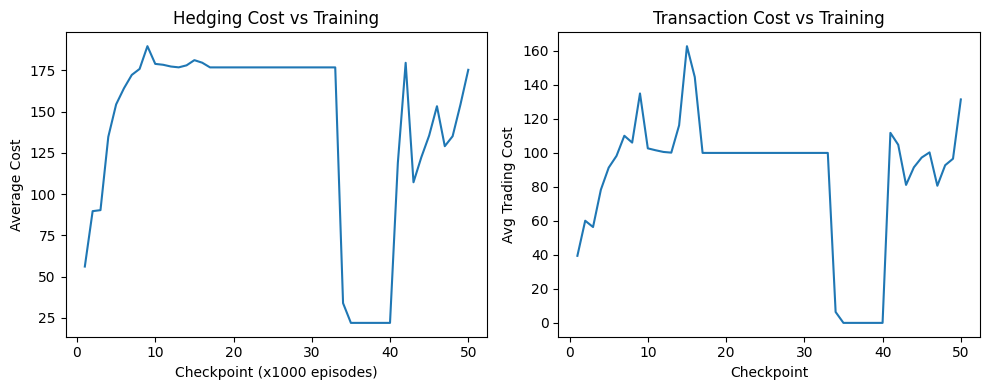

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(df_stability["checkpoint"], df_stability["avg_final_cost"])
plt.title("Hedging Cost vs Training")
plt.xlabel("Checkpoint (x1000 episodes)")
plt.ylabel("Average Cost")

plt.subplot(1,2,2)
plt.plot(df_stability["checkpoint"], df_stability["avg_transaction_cost"])
plt.title("Transaction Cost vs Training")
plt.xlabel("Checkpoint")
plt.ylabel("Avg Trading Cost")

plt.tight_layout()
plt.show()

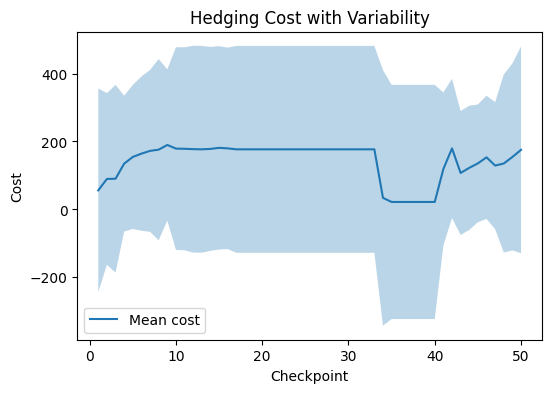

In [11]:
plt.figure(figsize=(6,4))

mean = df_stability["avg_final_cost"]
std = df_stability["std_reward"]  # proxy for variability

plt.plot(df_stability["checkpoint"], mean, label="Mean cost")
plt.fill_between(
    df_stability["checkpoint"],
    mean - std,
    mean + std,
    alpha=0.3
)

plt.title("Hedging Cost with Variability")
plt.xlabel("Checkpoint")
plt.ylabel("Cost")
plt.legend()
plt.show()

## Results and tests 

In [12]:
def evaluate_chunk(args):
    method, tag, model_params, scenario, n_episodes, seed = args

    agent = make_agent(model_params, n_episodes, seed)
    env = agent.env

    agent.epsilon = -1.0

    if method == "rl":
        agent.load(tag=tag)

    costs = []

    for i in range(n_episodes):
        obs = env.reset()
        done = False
        episode_reward = 0.0

        while not done:
            if method == "rl":
                x = np.asarray(obs).reshape(1, -1)
                action, _, _ = agent.egreedy_action(x)
                action = float(np.asarray(action).reshape(-1)[0])

            elif method == "delta":
                action = (
                    env.delta_path[i % env.num_path, env.t]
                    * env.num_contract
                    * 100
                )

            elif method == "bartlett":
                action = (
                    env.bartlett_delta_path[i % env.num_path, env.t]
                    * env.num_contract
                    * 100
                )

            else:
                raise ValueError(f"Unknown method: {method}")

            obs, reward, done, _ = env.step(action)
            episode_reward += float(reward)

        costs.append(-episode_reward)

    return costs


def evaluate_parallel(method, tag, model_params, scenario):
    tasks = []
    remaining = N_EPISODES
    seed = 123

    while remaining > 0:
        n = min(CHUNK_SIZE, remaining)
        tasks.append((method, tag, model_params, scenario, n, seed))
        remaining -= n
        seed += 1

    results = []

    with Pool(N_WORKERS) as pool:
        for j, chunk in enumerate(pool.imap_unordered(evaluate_chunk, tasks), 1):
            results.append(chunk)
            done = min(j * CHUNK_SIZE, N_EPISODES)
            print(f"{scenario} | {method}: Finished {done}/{N_EPISODES}")

    all_costs = [c for chunk in results for c in chunk]

    return pd.DataFrame({
        "scenario": scenario,
        "method": method,
        "episode": range(len(all_costs)),
        "final_cost": all_costs,
    })


In [13]:
# Option price SABR 

def bs_price(S, K, T, r, sigma):
    eps = 1e-8
    T = max(T, eps)
    sigma = max(sigma, eps)

    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    return S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)


def sabr_price(S, K, T, r, alpha, beta, rho, nu):
    # very simplified Hagan ATM-like approximation
    eps = 1e-8
    F = S

    if abs(F - K) < eps:
        sigma = alpha / (F**(1 - beta))
    else:
        z = (nu / alpha) * (F*K)**((1-beta)/2) * np.log(F/K)
        x_z = np.log((np.sqrt(1 - 2*rho*z + z*z) + z - rho)/(1 - rho))
        sigma = alpha * z / x_z

    sigma = max(sigma, 1e-6)

    return bs_price(S, K, T, r, sigma)

Fixed param training : In and Out of distribution tests

To reproduce **"analysis/final_costs_rl_delta_bartlett_100k_raw".csv** for baseline testing in and out of distribution, run the following commented code. It contains delta, bartlett and rl hedging and relative hedging cost per episode, frow which we derive **Table 1** of the report.

In [33]:
FINAL_TAG = "baseline_daily50"
N_EPISODES = 100_000
N_WORKERS = cpu_count()
CHUNK_SIZE = 2_000

# if __name__ == "__main__":

#     dfs = []

#     for scenario, params in [
#         ("baseline", BASELINE_SABR),
#         ("high_vol", HIGH_VOL_SABR),
#     ]:
#         for method in ["rl", "delta", "bartlett"]:
#             df_method = evaluate_parallel(
#                 method=method,
#                 tag=FINAL_TAG,
#                 model_params=params,
#                 scenario=scenario,
#             )
#             dfs.append(df_method)

#     df = pd.concat(dfs, ignore_index=True)

#     df["is_valid"] = np.isfinite(df["final_cost"])

#     df.to_csv("analysis/final_costs_rl_delta_bartlett_100k_raw.csv", index=False)



In [34]:
df_baseline = pd.read_csv("analysis/final_costs_rl_delta_bartlett_100k_valid.csv")
df_valid = df_baseline[df_baseline["is_valid"]].copy()


In [35]:
df_valid['option_price'] = np.where(df_valid['scenario'] == 'baseline', 
                                    sabr_price(100, 100, 20/200, 0, BASELINE_SABR['vol'], BASELINE_SABR['beta'], BASELINE_SABR['rho'], BASELINE_SABR['volvol']), 
                                    sabr_price(100, 100, 20/200, 0, HIGH_VOL_SABR['vol'], HIGH_VOL_SABR['beta'], HIGH_VOL_SABR['rho'], HIGH_VOL_SABR['volvol']))

df_valid['rel_cost'] = (df_valid['final_cost'] - df_valid['option_price']) / df_valid['option_price']
summary = df_valid.groupby(["scenario", "method"])["rel_cost"].agg(
    ["mean", "std", "median", "count"]
)
summary

mean         std     median   count
scenario method                                            
baseline bartlett  95.106197   98.634516  78.397906  100000
         delta     95.383033   98.387513  78.595684  100000
         rl        72.084594  125.013673  31.502467  100000
high_vol bartlett  63.018929   96.940633  44.701816  100000
         delta     63.207338   96.728200  44.893092  100000
         rl        47.824936  124.683885   7.973160  100000

Domain Randomization Training : Low and High volatility

To reproduce **"analysis/final_costs_rl_delta_bartlett_100k_randomized.csv"** for domain randomization testing for low and high vol, run the following commented code. It contains delta, bartlett and rl hedging and relative hedging cost per episode, frow which we derive **Table 2** of the report.

In [36]:

FINAL_TAG = "domain_randomized_daily50"
N_EPISODES = 100_000
N_WORKERS = cpu_count()
CHUNK_SIZE = 2_000

# if __name__ == "__main__":

#     dfs = []

#     for scenario, params in [
#         ("baseline", BASELINE_SABR),
#         ("high_vol", HIGH_VOL_SABR),
#     ]:
#         for method in ["rl", "delta", "bartlett"]:
#             df_method = evaluate_parallel(
#                 method=method,
#                 tag=FINAL_TAG,
#                 model_params=params,
#                 scenario=scenario,
#             )
#             dfs.append(df_method)

#     df = pd.concat(dfs, ignore_index=True)

#     df["is_valid"] = np.isfinite(df["final_cost"])

#     df.to_csv("analysis/final_costs_rl_delta_bartlett_100k_randomized.csv", index=False)


In [37]:
df_random = pd.read_csv("analysis/final_costs_rl_delta_bartlett_100k_randomized.csv")
df = df_random[df_random['is_valid']]

In [38]:
df['option_price'] = np.where(df['scenario'] == 'baseline', 
                                    sabr_price(100, 100, 20/200, 0, BASELINE_SABR['vol'], BASELINE_SABR['beta'], BASELINE_SABR['rho'], BASELINE_SABR['volvol']), 
                                    sabr_price(100, 100, 20/200, 0, HIGH_VOL_SABR['vol'], HIGH_VOL_SABR['beta'], HIGH_VOL_SABR['rho'], HIGH_VOL_SABR['volvol']))

df['rel_cost'] = (df['final_cost'] - df['option_price']) / df['option_price']
summary = df.groupby(["scenario", "method"])["rel_cost"].agg(
    ["mean", "std", "median", "count"]
)
summary

mean         std     median   count
scenario method                                            
baseline bartlett  95.106197   98.634516  78.397906  100000
         delta     95.383033   98.387513  78.595684  100000
         rl        72.084594  125.013673  31.502467  100000
high_vol bartlett  63.018929   96.940633  44.701816  100000
         delta     63.207338   96.728200  44.893092  100000
         rl        47.824936  124.683885   7.973160  100000

# Stochastic Trading Costs Extension.

In [39]:
# This code is consitent with state of dimension 4 including lambda_t : trading costs

def make_env(
    model_params,
    n_episodes,
    seed,
    stochastic_tc=False,
    lambda_spot_corr=0.0,
):
    return TradingEnv(
        continuous_action_flag=True,
        sabr_flag=True,
        dg_random_seed=seed,
        init_ttm=20,
        trade_freq=1,
        spread=0.01,
        num_contract=1,
        num_sim=n_episodes,
        model_params=model_params,

        stochastic_tc=stochastic_tc,
        lambda_bar=0.01,
        kappa=1.0,
        xi=0.3,
        lambda_spot_corr=lambda_spot_corr,
    )


def evaluate_chunk(args):
    (
        method,
        tag,
        model_params,
        scenario,
        n_episodes,
        seed,
        stochastic_tc,
        lambda_spot_corr,
    ) = args

    env = make_env(
        model_params=model_params,
        n_episodes=n_episodes,
        seed=seed,
        stochastic_tc=stochastic_tc,
        lambda_spot_corr=lambda_spot_corr,
    )

    agent = DDPG(env)
    agent.epsilon = -1.0

    if method == "rl":
        agent.load(tag=tag)

    costs = []

    for i in range(n_episodes):
        obs = env.reset()
        done = False
        episode_reward = 0.0

        while not done:
            if method == "rl":
                x = np.asarray(obs).reshape(1, -1)
                action, _, _ = agent.egreedy_action(x)
                action = float(np.asarray(action).reshape(-1)[0])

            elif method == "delta":
                action = (
                    env.delta_path[i % env.num_path, env.t]
                    * env.num_contract
                    * 100
                )

            elif method == "bartlett":
                action = (
                    env.bartlett_delta_path[i % env.num_path, env.t]
                    * env.num_contract
                    * 100
                )

            else:
                raise ValueError(f"Unknown method: {method}")

            obs, reward, done, _ = env.step(action)
            episode_reward += float(reward)

        costs.append(-episode_reward)

    return costs


def evaluate_parallel(
    method,
    tag,
    model_params,
    scenario,
    stochastic_tc=False,
    lambda_spot_corr=0.0,
):
    tasks = []
    remaining = N_EPISODES
    seed = 123

    while remaining > 0:
        n = min(CHUNK_SIZE, remaining)

        tasks.append((
            method,
            tag,
            model_params,
            scenario,
            n,
            seed,
            stochastic_tc,
            lambda_spot_corr,
        ))

        remaining -= n
        seed += 1

    results = []

    with Pool(N_WORKERS) as pool:
        for j, chunk in enumerate(pool.imap_unordered(evaluate_chunk, tasks), 1):
            results.append(chunk)
            done = min(j * CHUNK_SIZE, N_EPISODES)
            print(f"{scenario} | {method}: Finished {done}/{N_EPISODES}")

    all_costs = [c for chunk in results for c in chunk]

    return pd.DataFrame({
        "scenario": scenario,
        "method": method,
        "episode": range(len(all_costs)),
        "final_cost": all_costs,
    })

To reproduce **"analysis/final_costs_rl_delta_bartlett_stochTC_indep_50k.csv"** for stochastic independant trading costs testing only for low vol, run the following commented code. It contains delta, bartlett and rl hedging and relative hedging cost per episode, frow which we derive **Table 3 part 1** of the report.

In [21]:
FINAL_TAG = "stochTC_indep_daily20"
N_EPISODES = 50_000
N_WORKERS = cpu_count()
CHUNK_SIZE = 2_000

# if __name__ == "__main__":

#     dfs = []

#     for scenario, params in [
#         ("baseline", BASELINE_SABR)
#     ]:
#         for method in ["rl", "delta", "bartlett"]:
#             df_method = evaluate_parallel(
#                 method=method,
#                 tag=FINAL_TAG,
#                 model_params=params,
#                 scenario=scenario,
#                 stochastic_tc=True,
#                 lambda_spot_corr=0.0,
#             )
#             dfs.append(df_method)

#     df = pd.concat(dfs, ignore_index=True)

#     df["is_valid"] = np.isfinite(df["final_cost"])

#     df.to_csv("analysis/final_costs_rl_delta_bartlett_stochTC_indep_50k.csv", index=False)

In [22]:
df = pd.read_csv("analysis/final_costs_rl_delta_bartlett_stochTC_indep_50k.csv")
df_valid = df[df['is_valid']]

In [23]:
df_valid['option_price'] = np.where(df_valid['scenario'] == 'baseline', 
                                    sabr_price(100, 100, 20/200, 0, BASELINE_SABR['vol'], BASELINE_SABR['beta'], BASELINE_SABR['rho'], BASELINE_SABR['volvol']), 
                                    sabr_price(100, 100, 20/200, 0, HIGH_VOL_SABR['vol'], HIGH_VOL_SABR['beta'], HIGH_VOL_SABR['rho'], HIGH_VOL_SABR['volvol']))

df_valid['rel_cost'] = (df_valid['final_cost'] - df_valid['option_price']) / df_valid['option_price']
summary = df_valid.groupby(["scenario", "method"])["rel_cost"].agg(
    ["mean", "std", "median", "count"]
)
summary

mean         std     median  count
scenario method                                           
baseline bartlett  94.630840   98.582653  78.126985  50000
         delta     94.902393   98.332349  78.034934  50000
         rl        70.540145  103.429800  32.311327  50000

To reproduce **"analysis/final_costs_rl_delta_bartlett_stochTC_corr_50k.csv"** for stochastic correlated trading costs testing only for low vol, run the following commented code. It contains delta, bartlett and rl hedging and relative hedging cost per episode, frow which we derive **Table 3 part 2** of the report.

In [24]:
FINAL_TAG = "stochTC_corr_daily20"
N_EPISODES = 50_000
N_WORKERS = cpu_count()
CHUNK_SIZE = 2_000

# if __name__ == "__main__":

#     dfs = []

#     for scenario, params in [
#         ("baseline", BASELINE_SABR)
#     ]:
#         for method in ["rl", "delta", "bartlett"]:
#             df_method = evaluate_parallel(
#                 method=method,
#                 tag=FINAL_TAG,
#                 model_params=params,
#                 scenario=scenario,
#                 stochastic_tc=True,
#                 lambda_spot_corr=-0.7,
#             )
#             dfs.append(df_method)

#     df = pd.concat(dfs, ignore_index=True)

#     df["is_valid"] = np.isfinite(df["final_cost"])

#     df.to_csv("analysis/final_costs_rl_delta_bartlett_stochTC_corr_50k.csv", index=False)

In [25]:
df = pd.read_csv("analysis/final_costs_rl_delta_bartlett_stochTC_corr_50k.csv")
df_valid = df[df['is_valid']]

In [26]:
df_valid['option_price'] = np.where(df_valid['scenario'] == 'baseline', 
                                    sabr_price(100, 100, 20/200, 0, BASELINE_SABR['vol'], BASELINE_SABR['beta'], BASELINE_SABR['rho'], BASELINE_SABR['volvol']), 
                                    sabr_price(100, 100, 20/200, 0, HIGH_VOL_SABR['vol'], HIGH_VOL_SABR['beta'], HIGH_VOL_SABR['rho'], HIGH_VOL_SABR['volvol']))

df_valid['rel_cost'] = (df_valid['final_cost'] - df_valid['option_price']) / df_valid['option_price']
summary = df_valid.groupby(["scenario", "method"])["rel_cost"].agg(
    ["mean", "std", "median", "count"]
)
summary

mean        std     median  count
scenario method                                          
baseline bartlett  94.581977  98.504805  78.038152  50000
         delta     94.858012  98.282663  78.016482  50000
         rl        70.715954  82.303930  52.342053  50000

The following code looks into the behaviour of the policy throught the live of the option for each episode. In particular, it studies the hedging cost proxy to assess the diffrences of behaviour in the independant vs correlated Trading costs.

In [27]:
N_EPISODES = 10_000   

def make_env(
    model_params,
    n_episodes,
    seed=123,
    stochastic_tc=True,
    lambda_spot_corr=-0.7,
):
    return TradingEnv(
        continuous_action_flag=True,
        sabr_flag=True,
        dg_random_seed=seed,
        init_ttm=20,
        trade_freq=1,
        spread=0.01,
        num_contract=1,
        num_sim=n_episodes,
        model_params=model_params,
        domain_randomization=False,

        stochastic_tc=stochastic_tc,
        lambda_bar=0.01,
        kappa=1.0,
        xi=0.3,
        lambda_spot_corr=lambda_spot_corr,
    )


def collect_policy_reaction(
    tag,
    model_params,
    n_episodes=N_EPISODES,
    stochastic_tc=True,
    lambda_spot_corr=-0.7,
):
    env = make_env(
        model_params=model_params,
        n_episodes=n_episodes,
        stochastic_tc=stochastic_tc,
        lambda_spot_corr=lambda_spot_corr,
    )

    agent = DDPG(env)
    agent.load(tag=tag)
    agent.epsilon = -1.0

    rows = []

    for ep in range(n_episodes):
        obs = env.reset()
        done = False

        while not done:
            current_price = float(env.state[0])
            current_position = float(env.state[1])
            ttm = float(env.state[2])

            if stochastic_tc:
                lambda_t = float(env.state[3])
            else:
                lambda_t = env.spread

            x = np.asarray(obs).reshape(1, -1).astype(np.float32)

            action, _, _ = agent.egreedy_action(x)
            action = float(np.asarray(action).reshape(-1)[0])

            trade_size = abs(action - current_position)

            rows.append({
                "episode": ep,
                "time": env.t,
                "spot": current_price,
                "ttm": ttm,
                "lambda_t": lambda_t,
                "position_before": current_position,
                "position_after": action,
                "trade_size": trade_size,
            })

            obs, reward, done, info = env.step(action)

        if (ep + 1) % 1000 == 0:
            print(f"Finished {ep + 1}/{n_episodes}")

    return pd.DataFrame(rows)


To reproduce **"analysis/policy_reaction_lambda_trade_corr.csv"**, run the following commented code.

In [28]:

# TAG = "stochTC_corr_daily20"   

# df_policy = collect_policy_reaction(
#     tag=TAG,
#     model_params=BASELINE_SABR,
#     n_episodes=N_EPISODES,
#     stochastic_tc=True,
#     lambda_spot_corr=-0.7,   
# )

# df_policy.to_csv("analysis/policy_reaction_lambda_trade_corr.csv", index=False)


In [29]:
df_corr = pd.read_csv("analysis/policy_reaction_lambda_trade_corr.csv")

print(df_corr.head())
print(df_corr[["lambda_t", "trade_size"]].corr())

   episode  time        spot   ttm  lambda_t  position_before  position_after  \
0        0     0  100.000000  20.0  0.010000         0.000000       53.766323   
1        0     1  101.915763  19.0  0.009942        53.766323       65.442429   
2        0     2  100.730103  18.0  0.009999        65.442429       73.068962   
3        0     3  102.182823  17.0  0.010113        73.068962       78.083824   
4        0     4  100.741851  16.0  0.010287        78.083824       78.587326   

   trade_size  
0   53.766323  
1   11.676105  
2    7.626534  
3    5.014862  
4    0.503502  
            lambda_t  trade_size
lambda_t    1.000000    0.001195
trade_size  0.001195    1.000000


To reproduce **"analysis/policy_reaction_lambda_trade_indep.csv"**, run the following commented code.

In [30]:
# N_EPISODES = 10_000   
# TAG = "stochTC_indep_daily20"  

# df_policy = collect_policy_reaction(
#     tag=TAG,
#     model_params=BASELINE_SABR,
#     n_episodes=N_EPISODES,
#     stochastic_tc=True,
#     lambda_spot_corr=0,  
# )

# df_policy.to_csv("analysis/policy_reaction_lambda_trade_indep.csv", index=False)


In [31]:
df_indep = pd.read_csv("analysis/policy_reaction_lambda_trade_indep.csv")
print(df_indep.head())
print(df_indep[["lambda_t", "trade_size"]].corr())

   episode  time        spot   ttm  lambda_t  position_before  position_after  \
0        0     0  100.000000  20.0  0.010000         0.000000       85.433113   
1        0     1  101.915763  19.0  0.009927        85.433113       91.331863   
2        0     2  100.730103  18.0  0.009660        91.331863       91.744766   
3        0     3  102.182823  17.0  0.009649        91.744766       90.696289   
4        0     4  100.741851  16.0  0.009550        90.696289       89.813683   

   trade_size  
0   85.433113  
1    5.898750  
2    0.412903  
3    1.048477  
4    0.882607  
            lambda_t  trade_size
lambda_t    1.000000    0.000671
trade_size  0.000671    1.000000


Further analysis


Independent lambda/trade summary:
           lambda_bin  avg_lambda  avg_trade_size  median_trade_size  count
0  (0.00628, 0.00922]    0.008894        4.149819           0.818722  20000
1  (0.00922, 0.00952]    0.009386        2.803906           0.722542  20000
2  (0.00952, 0.00972]    0.009626        2.540194           0.722042  20000
3  (0.00972, 0.00988]    0.009801        2.488463           0.749462  20000
4     (0.00988, 0.01]    0.009962       33.305726           2.361290  26971
5      (0.01, 0.0101]    0.010047        2.638182           0.791245  13029
6    (0.0101, 0.0103]    0.010171        2.513812           0.764111  20000
7    (0.0103, 0.0105]    0.010348        2.540342           0.735428  20000
8    (0.0105, 0.0108]    0.010603        2.887308           0.728317  20000
9    (0.0108, 0.0141]    0.011192        4.016911           0.798439  20000

Correlated lambda/trade summary:
           lambda_bin  avg_lambda  avg_trade_size  median_trade_size  count
0  (0.00663, 0.0094

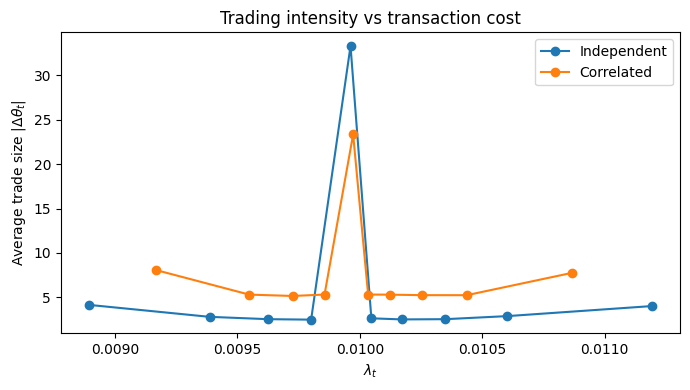

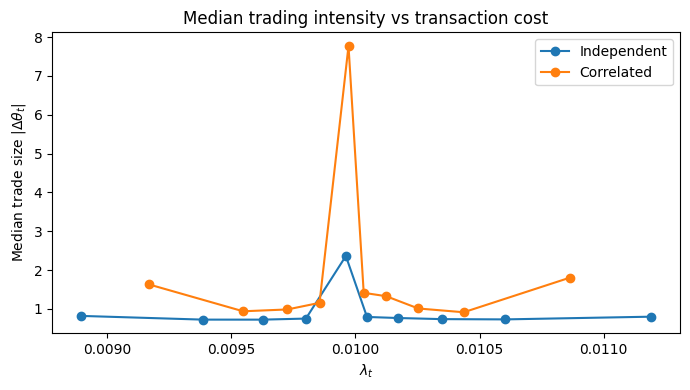

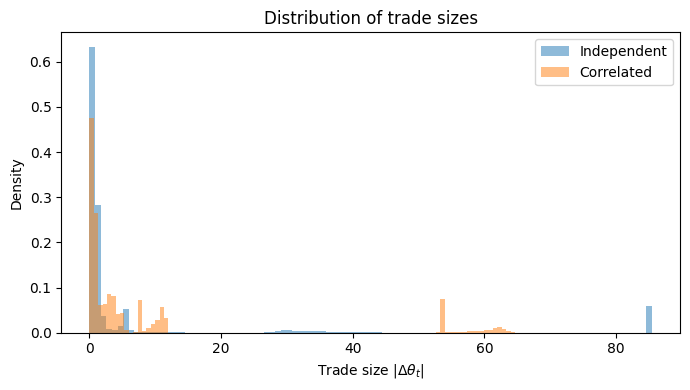

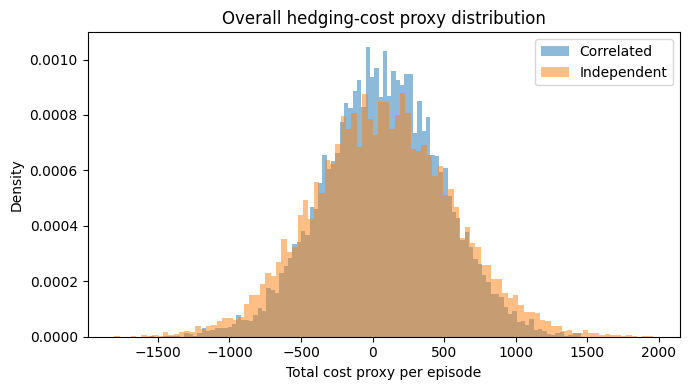

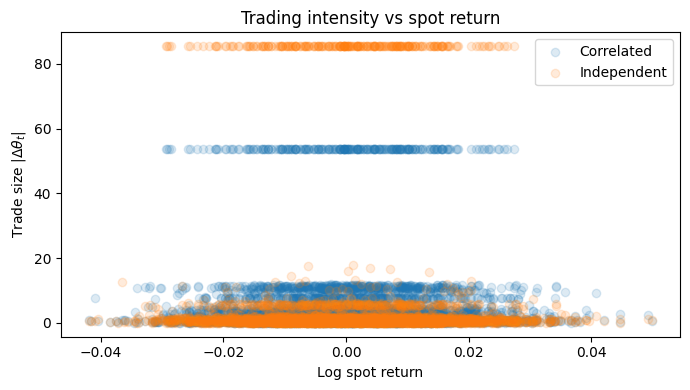

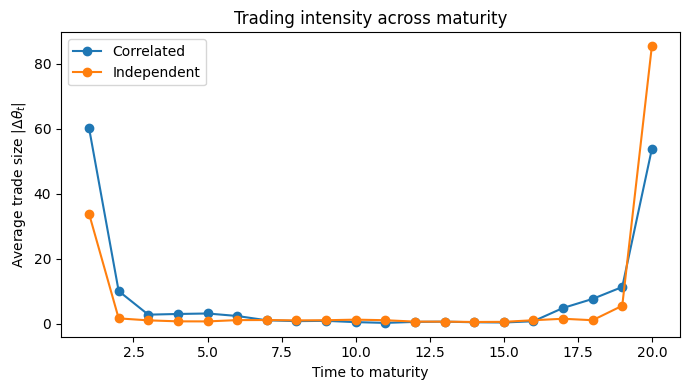

In [32]:

df_indep["case"] = "Independent"
df_corr["case"] = "Correlated"

df_all = pd.concat([df_indep, df_corr], ignore_index=True)

# --------------------------------------------------
# 1. Basic diagnostics
# --------------------------------------------------

df_all["spot_next"] = df_all.groupby(["case", "episode"])["spot"].shift(-1)
df_all["spot_return"] = np.log(df_all["spot_next"] / df_all["spot"])

# Transaction cost per step
df_all["transaction_cost"] = (
    df_all["spot"]
    * df_all["lambda_t"]
    * df_all["trade_size"]
)

# Hedge PnL proxy
df_all["hedge_pnl"] = (
    (df_all["spot_next"] - df_all["spot"])
    * df_all["position_after"]
)

# Cost proxy: transaction cost minus hedge PnL
df_all["step_cost_proxy"] = (
    df_all["transaction_cost"]
    - df_all["hedge_pnl"]
)

df_all = df_all.replace([np.inf, -np.inf], np.nan)

# --------------------------------------------------
# 2. Lambda vs trade-size summary
# --------------------------------------------------

def lambda_trade_summary(df, n_bins=10):
    tmp = df.dropna(subset=["lambda_t", "trade_size"]).copy()
    tmp["lambda_bin"] = pd.qcut(tmp["lambda_t"], n_bins, duplicates="drop")

    return tmp.groupby("lambda_bin", observed=True).agg(
        avg_lambda=("lambda_t", "mean"),
        avg_trade_size=("trade_size", "mean"),
        median_trade_size=("trade_size", "median"),
        count=("trade_size", "count"),
    ).reset_index()


agg_indep = lambda_trade_summary(df_indep)
agg_corr = lambda_trade_summary(df_corr)

print("\nIndependent lambda/trade summary:")
print(agg_indep)

print("\nCorrelated lambda/trade summary:")
print(agg_corr)

print("\nCorrelation Independent:")
print(df_indep[["lambda_t", "trade_size"]].corr())

print("\nCorrelation Correlated:")
print(df_corr[["lambda_t", "trade_size"]].corr())

# --------------------------------------------------
# 3. Overall hedge-performance proxy per episode
# --------------------------------------------------

episode_perf = (
    df_all
    .dropna(subset=["step_cost_proxy"])
    .groupby(["case", "episode"])
    .agg(
        total_tc=("transaction_cost", "sum"),
        total_hedge_pnl=("hedge_pnl", "sum"),
        total_cost_proxy=("step_cost_proxy", "sum"),
        avg_lambda=("lambda_t", "mean"),
        total_trade=("trade_size", "sum"),
        max_trade=("trade_size", "max"),
    )
    .reset_index()
)

summary_perf = episode_perf.groupby("case").agg(
    mean_cost=("total_cost_proxy", "mean"),
    std_cost=("total_cost_proxy", "std"),
    median_cost=("total_cost_proxy", "median"),
    q90_cost=("total_cost_proxy", lambda x: x.quantile(0.90)),
    q95_cost=("total_cost_proxy", lambda x: x.quantile(0.95)),
    q99_cost=("total_cost_proxy", lambda x: x.quantile(0.99)),
    mean_total_tc=("total_tc", "mean"),
    mean_total_trade=("total_trade", "mean"),
    count=("total_cost_proxy", "count"),
)

print("\nOverall hedge-performance proxy:")
print(summary_perf)

# --------------------------------------------------
# 4. Plots
# --------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(
    agg_indep["avg_lambda"],
    agg_indep["avg_trade_size"],
    marker="o",
    label="Independent"
)
plt.plot(
    agg_corr["avg_lambda"],
    agg_corr["avg_trade_size"],
    marker="o",
    label="Correlated"
)
plt.xlabel(r"$\lambda_t$")
plt.ylabel(r"Average trade size $|\Delta \theta_t|$")
plt.title("Trading intensity vs transaction cost")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(
    agg_indep["avg_lambda"],
    agg_indep["median_trade_size"],
    marker="o",
    label="Independent"
)
plt.plot(
    agg_corr["avg_lambda"],
    agg_corr["median_trade_size"],
    marker="o",
    label="Correlated"
)
plt.xlabel(r"$\lambda_t$")
plt.ylabel(r"Median trade size $|\Delta \theta_t|$")
plt.title("Median trading intensity vs transaction cost")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.hist(
    df_indep["trade_size"].dropna(),
    bins=100,
    alpha=0.5,
    density=True,
    label="Independent"
)
plt.hist(
    df_corr["trade_size"].dropna(),
    bins=100,
    alpha=0.5,
    density=True,
    label="Correlated"
)
plt.xlabel(r"Trade size $|\Delta \theta_t|$")
plt.ylabel("Density")
plt.title("Distribution of trade sizes")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
for case, tmp in episode_perf.groupby("case"):
    plt.hist(
        tmp["total_cost_proxy"],
        bins=100,
        alpha=0.5,
        density=True,
        label=case,
    )

plt.xlabel("Total cost proxy per episode")
plt.ylabel("Density")
plt.title("Overall hedging-cost proxy distribution")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
for case, tmp in df_all.dropna(subset=["spot_return"]).groupby("case"):
    sampled = tmp.sample(min(5000, len(tmp)), random_state=1)
    plt.scatter(
        sampled["spot_return"],
        sampled["trade_size"],
        alpha=0.15,
        label=case,
    )

plt.xlabel("Log spot return")
plt.ylabel(r"Trade size $|\Delta \theta_t|$")
plt.title("Trading intensity vs spot return")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
for case, tmp in df_all.groupby("case"):
    by_ttm = tmp.groupby("ttm")["trade_size"].mean()
    plt.plot(by_ttm.index, by_ttm.values, marker="o", label=case)

plt.xlabel("Time to maturity")
plt.ylabel(r"Average trade size $|\Delta \theta_t|$")
plt.title("Trading intensity across maturity")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 5. Save outputs
# --------------------------------------------------

episode_perf.to_csv("analysis/episode_performance_indep_vs_corr.csv", index=False)
summary_perf.to_csv("analysis/summary_performance_indep_vs_corr.csv")
agg_indep.to_csv("analysis/lambda_trade_summary_indep.csv", index=False)
agg_corr.to_csv("analysis/lambda_trade_summary_corr.csv", index=False)